### Multi box plots 
- Data used for main results
- Box plots recreated for easier reading
- Multiple boxplots plotted together

In [1]:
# Imports for functionality 
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from dissertation_simulations.plotting import plot_summary_boxplots
from dissertation_simulations.exponents import generate_spatial_exponent_matrix, generate_2D_exponent_matrix
from dissertation_simulations.loading_summaries import load_distribution_summary
from dissertation_simulations.plotting import add_significance_bracket
from dissertation_simulations.plotting import cohens_d
from dissertation_simulations.plotting import tukey_with_cohens_d
from dissertation_simulations.plotting import add_panel_tukey_brackets

import pandas as pd
import statsmodels.api as sm

from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
sns.set_theme(
    style="white",
    context="paper",
)

##### Figure 4

In [19]:
# Define exponent matrix
exp_matrix = generate_spatial_exponent_matrix(grid_shape=(1, 5), exp_min=-1.5, exp_max=-1, pattern="middle")
exp_matrix

array([[-1.  , -1.25, -1.5 , -1.25, -1.  ]])

In [20]:
# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults1_ts_exp_matrix_radial_-1-1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults2_psd_exp_matrix_radial_-1-1.5.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp1bresults3_specmod_exp_matrix_radial_-1-1.5.json"
]

labels = [
    "Average time series",
    "Average linear PSD",
    "Average spectral model"
]


distribution_index = 0 

all_estimates = []
all_methods = []

for path, label in zip(summary_paths, labels):
    electrodes, distributions = load_distribution_summary(path)

    estimates = np.asarray(distributions[distribution_index])

    all_estimates.extend(estimates)
    all_methods.extend([label] * len(estimates))

df = pd.DataFrame({
    "estimate": all_estimates,
    "method": all_methods,
})

print(df.groupby("method")["estimate"].agg(["count", "mean", "std"]))

                        count      mean       std
method                                           
Average linear PSD        100  1.188755  0.026492
Average spectral model    100  1.212571  0.027188
Average time series       100  1.189178  0.060694


In [21]:
# Run the ANOVA - 1 way, effect of averaging method
model = ols("estimate ~ C(method)", data=df).fit()

anova_results = sm.stats.anova_lm(model, typ=2)

print("\nOne-way ANOVA:")
print(anova_results)


One-way ANOVA:
             sum_sq     df          F    PR(>F)
C(method)  0.037153    2.0  10.874341  0.000028
Residual   0.507355  297.0        NaN       NaN


In [25]:
method_tukey, method_posthoc = tukey_with_cohens_d(
    data=df,
    factor_column="method",
)

print("\nTukey HSD results with Cohen's d:")
print(method_posthoc.round(3))


Tukey HSD results with Cohen's d:
                   group1                  group2  mean_difference  \
0      Average linear PSD  Average spectral model            0.024   
1      Average linear PSD     Average time series            0.000   
2  Average spectral model     Average time series           -0.023   

   p_adjusted  ci_lower  ci_upper  significant  cohens_d  
0       0.000     0.010     0.038         True    -0.887  
1       0.997    -0.013     0.014        False    -0.009  
2       0.000    -0.037    -0.010         True     0.497  


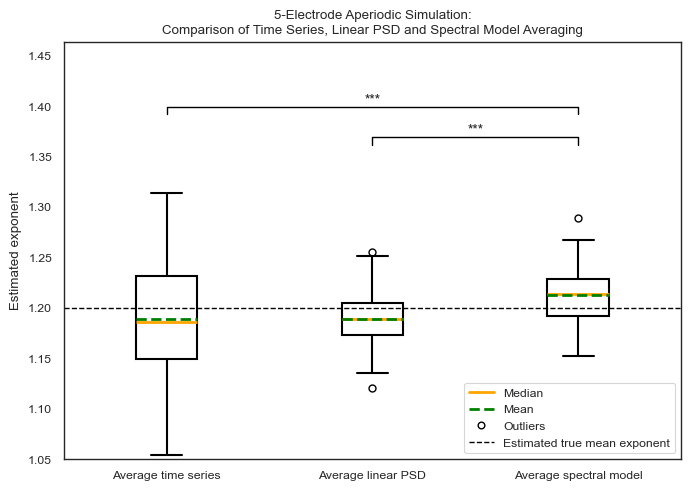

In [27]:
common_ylim = (1.05, 1.35)

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels,
    title=(
        "5-Electrode Aperiodic Simulation:\n"
        "Comparison of Time Series, Linear PSD and Spectral Model Averaging"
    ),
    true_mean_exp=np.mean(-exp_matrix),
    ylabel="Estimated exponent",
    ylim=common_ylim,
    show=False,
)

# Add brackets only for Tukey comparisons where reject=True.
bracket_posthoc = add_panel_tukey_brackets(
    ax=ax,
    panel_data=df,
    base_ylim=common_ylim,
    labels=labels,
)

fig.tight_layout()
plt.show()

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures Final\Figure 4.png", dpi=300, bbox_inches="tight")

##### Figure 5

In [3]:
common_ylim = (1.25, 1.6)
third_ylim = (0.5, 2.5)

labels = [
    "Average linear PSD",
    "Average log PSD",
    "Average spectral model",
]

distribution_index = 0

panel_configs = [
    {
        "simulation_type": "Aperiodic simulation",
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
        "ylim": common_ylim,
        "true_mean_exp": np.mean(
            -generate_2D_exponent_matrix(
                grid_shape=(1, 5),
                exp_range=(-2, -1),
                gradient_axis="cols",
            )
        ),
    },
    {
        "simulation_type": "Combined simulation",
        "title": (
            "5-Electrode Combined Simulation:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1aresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
        "ylim": common_ylim,
        "true_mean_exp": np.mean(
            -generate_2D_exponent_matrix(
                grid_shape=(1, 5),
                exp_range=(-2, -1),
                gradient_axis="cols",
            )
        ),
    },
    {
        "simulation_type": "EEG data",
        "title": (
            "5-Electrode Centre Mid-line EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults1_eeg_psd_linear_5elec_midline.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults2_eeg_psd_log_5elec_midline.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults3_eeg_specmod_5elec_midline.json",
        ],
        "ylim": third_ylim,
        "true_mean_exp": None,
    },
]

In [4]:
data_rows = []

for panel in panel_configs:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "simulation_type": panel["simulation_type"],
            })

df = pd.DataFrame(data_rows)

print(df.groupby(["simulation_type", "method"])["estimate"].agg(
    ["count", "mean", "std"]
).round(3))

                                             count   mean    std
simulation_type      method                                     
Aperiodic simulation Average linear PSD        100  1.421  0.032
                     Average log PSD           100  1.510  0.024
                     Average spectral model    100  1.520  0.025
Combined simulation  Average linear PSD        100  1.392  0.024
                     Average log PSD           100  1.505  0.022
                     Average spectral model    100  1.498  0.020
EEG data             Average linear PSD        111  1.701  0.331
                     Average log PSD           111  1.700  0.315
                     Average spectral model    111  1.706  0.320


In [5]:
two_way_model = ols(
    "estimate ~ C(method) + C(simulation_type)",
    data=df,
).fit()

two_way_anova = sm.stats.anova_lm(two_way_model, typ=2)

print("\nTwo-way ANOVA (no interaction):")
print(two_way_anova)

# omnibus effect sizes: partial eta-squared
residual_ss = two_way_anova.loc["Residual", "sum_sq"]

for factor in ["C(method)", "C(simulation_type)"]:
    partial_eta_squared = (
        two_way_anova.loc[factor, "sum_sq"]
        / (two_way_anova.loc[factor, "sum_sq"] + residual_ss)
    )
    print(f"{factor} partial eta-squared: {partial_eta_squared:.3f}")


Two-way ANOVA (no interaction):
                       sum_sq     df           F        PR(>F)
C(method)            0.903264    2.0   11.974894  7.334082e-06
C(simulation_type)  11.187292    2.0  148.313962  1.283310e-56
Residual            34.999426  928.0         NaN           NaN
C(method) partial eta-squared: 0.025
C(simulation_type) partial eta-squared: 0.242


In [6]:
method_tukey, method_posthoc = tukey_with_cohens_d(df, "method")
simulation_tukey, simulation_posthoc = tukey_with_cohens_d(
    df,
    "simulation_type",
)

print("\nPost-hoc comparisons: averaging method")
print(method_posthoc.round(3))

print("\nPost-hoc comparisons: simulation type")
print(simulation_posthoc.round(3))


Post-hoc comparisons: averaging method
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.064       0.001   
1  Average linear PSD  Average spectral model            0.068       0.000   
2     Average log PSD  Average spectral model            0.003       0.983   

   ci_lower  ci_upper  significant  cohens_d  
0     0.022     0.106         True    -0.283  
1     0.026     0.110         True    -0.295  
2    -0.039     0.045        False    -0.015  

Post-hoc comparisons: simulation type
                 group1               group2  mean_difference  p_adjusted  \
0  Aperiodic simulation  Combined simulation           -0.018       0.483   
1  Aperiodic simulation             EEG data            0.219       0.000   
2   Combined simulation             EEG data            0.237       0.000   

   ci_lower  ci_upper  significant  cohens_d  
0    -0.056     0.019        False     0.341  
1     0.182     0


Within-panel post-hoc tests: Aperiodic simulation
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.089       0.000   
1  Average linear PSD  Average spectral model            0.100       0.000   
2     Average log PSD  Average spectral model            0.011       0.014   

   ci_lower  ci_upper  significant  cohens_d  
0     0.080     0.098         True    -3.110  
1     0.090     0.109         True    -3.459  
2     0.002     0.020         True    -0.451  

Within-panel post-hoc tests: Combined simulation
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.112       0.000   
1  Average linear PSD  Average spectral model            0.106       0.000   
2     Average log PSD  Average spectral model           -0.007       0.065   

   ci_lower  ci_upper  significant  cohens_d  
0     0.105     0.120         True    

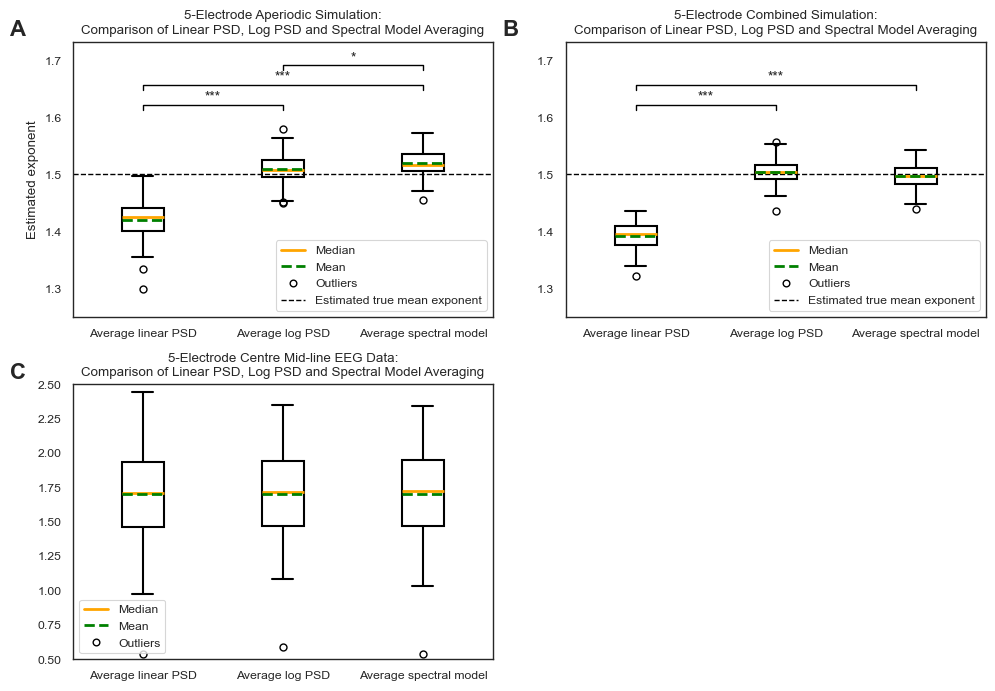

In [7]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharey=False,
)

axes = axes.ravel()

for i, panel in enumerate(panel_configs):
    plot_summary_boxplots(
        summary_paths=panel["summary_paths"],
        labels=labels,
        title=panel["title"],
        true_mean_exp=panel["true_mean_exp"],
        ylim=panel["ylim"],
        ylabel="Estimated exponent" if i == 0 else "",
        ax=axes[i],
        show=False,
    )

    panel_data = df.loc[
        df["simulation_type"] == panel["simulation_type"]
    ]

    panel_posthoc = add_panel_tukey_brackets(
        ax=axes[i],
        panel_data=panel_data,
        base_ylim=panel["ylim"],
        labels=labels
    )

    print(f"\nWithin-panel post-hoc tests: {panel['simulation_type']}")
    print(panel_posthoc.round(3))


# Hide unused final panel.
axes[3].axis("off")

# Panel labels.
for ax, letter in zip(axes[:3], ["A", "B", "C"]):
    ax.text(
        -0.15,
        1.08,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\Figure5.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### Figure 6

In [28]:
common_ylim = (1.08, 1.3)

labels = [
    "Average linear PSD",
    "Average log PSD",
    "Average spectral model",
]
anova_panels = [
    {
        "electrode_count": "5 electrodes",
        "simulation_type": "Aperiodic",
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5bresults1_psd_linear_exp_matrix_middle_-1-1.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5bresults2_psd_log_exp_matrix_middle_-1-1.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5bresults3_specmod_exp_matrix_middle_-1-2.json",
        ],
    },
    {
        "electrode_count": "5 electrodes",
        "simulation_type": "Combined",
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults1_psd_linear_exp_matrix_middle_-1-1.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults2_psd_log_exp_matrix_middle_-1-1.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp1bresults3_specmod_exp_matrix_middle_-1-1.5.json",
        ],
    },
    {
        "electrode_count": "25 electrodes",
        "simulation_type": "Aperiodic",
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\exp6bresults1_psd_linear_exp_matrix_middle_-1-1.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\exp6bresults2_psd_log_exp_matrix_middle_-1-1.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\exp6bresults3_specmod_exp_matrix_middle_-1-1.5.json",
        ],
    },
    {
        "electrode_count": "25 electrodes",
        "simulation_type": "Combined",
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\Combined\exp2bresults1_psd_linear_exp_matrix_middle_-1-1.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\Combined\exp2bresults2_psd_log_exp_matrix_middle_-1-1.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\2D electrodes\Combined\exp2bresults3_specmod_exp_matrix_middle_-1-1.5.json",
        ],
    },
]

In [29]:
data_rows = []

for panel in anova_panels:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "electrode_count": panel["electrode_count"],
                "simulation_type": panel["simulation_type"],
            })

df_3way = pd.DataFrame(data_rows)

print(
    df_3way.groupby(
        ["electrode_count", "simulation_type", "method"]
    )["estimate"].agg(["count", "mean", "std"]).round(3)
)

                                                        count   mean    std
electrode_count simulation_type method                                     
25 electrodes   Aperiodic       Average linear PSD        100  1.179  0.010
                                Average log PSD           100  1.202  0.012
                                Average spectral model    100  1.213  0.011
                Combined        Average linear PSD        100  1.171  0.008
                                Average log PSD           100  1.195  0.009
                                Average spectral model    100  1.194  0.008
5 electrodes    Aperiodic       Average linear PSD        100  1.184  0.028
                                Average log PSD           100  1.203  0.029
                                Average spectral model    100  1.208  0.026
                Combined        Average linear PSD        100  1.171  0.019
                                Average log PSD           100  1.193  0.017
            

In [54]:
three_way_model = ols(
    "estimate ~ C(method) + C(electrode_count) + C(simulation_type)",
    data=df_3way,
).fit()

three_way_anova = sm.stats.anova_lm(
    three_way_model,
    typ=2,
)

print("\nThree-way ANOVA: main effects only")
print(three_way_anova)

# omnibus effect sizes: partial eta-squared
residual_ss = three_way_anova.loc["Residual", "sum_sq"]

for factor in ["C(method)", "C(electrode_count)", "C(simulation_type)"]:
    partial_eta_squared = (
        three_way_anova.loc[factor, "sum_sq"]
        / (three_way_anova.loc[factor, "sum_sq"] + residual_ss)
    )
    print(f"{factor} partial eta-squared: {partial_eta_squared:.3f}")




Three-way ANOVA: main effects only
                      sum_sq      df           F        PR(>F)
C(method)           0.156609     2.0  241.212039  1.007412e-88
C(electrode_count)  0.000002     1.0    0.007393  9.314942e-01
C(simulation_type)  0.041684     1.0  128.405177  2.411376e-28
Residual            0.387933  1195.0         NaN           NaN
C(method) partial eta-squared: 0.288
C(electrode_count) partial eta-squared: 0.000
C(simulation_type) partial eta-squared: 0.097


In [31]:
method_tukey, method_posthoc = tukey_with_cohens_d(
    data=df_3way,
    factor_column="method",
)

print("\nMethod post-hoc comparisons:")
print(method_posthoc.round(3))


Method post-hoc comparisons:
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.022       0.000   
1  Average linear PSD  Average spectral model            0.026       0.000   
2     Average log PSD  Average spectral model            0.004       0.021   

   ci_lower  ci_upper  significant  cohens_d  
0     0.019     0.025         True    -1.183  
1     0.023     0.029         True    -1.358  
2     0.000     0.007         True    -0.188  


In [32]:
five_electrode = df_3way.loc[
    df_3way["electrode_count"] == "5 electrodes",
    "estimate",
]

twenty_five_electrode = df_3way.loc[
    df_3way["electrode_count"] == "25 electrodes",
    "estimate",
]

print(
    "Cohen's d: 5 minus 25 electrodes =",
    round(cohens_d(five_electrode, twenty_five_electrode), 3),
)

Cohen's d: 5 minus 25 electrodes = -0.004


In [33]:
common_ylim = (1.08, 1.3)

# Add plotting details to the four panel dictionaries.
exp_matrix_5 = generate_spatial_exponent_matrix(
    grid_shape=(1, 5),
    exp_min=-1.5,
    exp_max=-1,
    pattern="middle",
)

exp_matrix_25 = generate_spatial_exponent_matrix(
    grid_shape=(5, 5),
    exp_min=-1.5,
    exp_max=-1,
    pattern="middle",
)

anova_panels[0]["title"] = (
    "5-Electrode Aperiodic Simulation:\n"
    "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
)
anova_panels[0]["true_mean_exp"] = np.mean(-exp_matrix_5)

anova_panels[1]["title"] = (
    "5-Electrode Combined Simulation:\n"
    "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
)
anova_panels[1]["true_mean_exp"] = np.mean(-exp_matrix_5)

anova_panels[2]["title"] = (
    "25-Electrode Aperiodic Simulation:\n"
    "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
)
anova_panels[2]["true_mean_exp"] = np.mean(-exp_matrix_25)

anova_panels[3]["title"] = (
    "25-Electrode Combined Simulation:\n"
    "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
)
anova_panels[3]["true_mean_exp"] = np.mean(-exp_matrix_25)


Post-hoc results: 5 electrodes — Aperiodic
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.019       0.000   
1  Average linear PSD  Average spectral model            0.024       0.000   
2     Average log PSD  Average spectral model            0.005       0.388   

   ci_lower  ci_upper  significant  cohens_d  
0     0.010     0.028         True    -0.670  
1     0.015     0.033         True    -0.901  
2    -0.004     0.014        False    -0.186  

Post-hoc results: 5 electrodes — Combined
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.022       0.000   
1  Average linear PSD  Average spectral model            0.022       0.000   
2     Average log PSD  Average spectral model           -0.000       0.993   

   ci_lower  ci_upper  significant  cohens_d  
0     0.016     0.028         True    -1.209  
1    

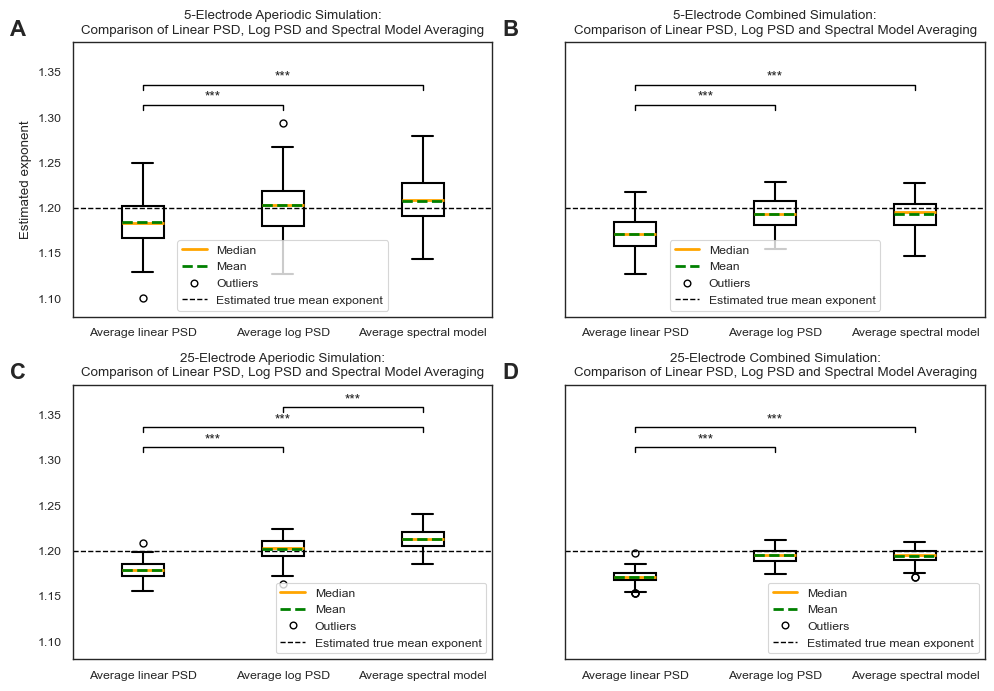

In [34]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharey=True,
)

axes = axes.ravel()

panel_posthoc_results = {}

for i, panel in enumerate(anova_panels):
    # Draw the three-box plot for this panel.
    plot_summary_boxplots(
        summary_paths=panel["summary_paths"],
        labels=labels,
        title=panel["title"],
        true_mean_exp=panel["true_mean_exp"],
        ylim=common_ylim,
        ylabel="Estimated exponent" if i == 0 else "",
        ax=axes[i],
        show=False,
    )

    # Select only the observations belonging to this panel.
    panel_data = df_3way.loc[
        (df_3way["electrode_count"] == panel["electrode_count"])
        & (df_3way["simulation_type"] == panel["simulation_type"])
    ]

    # Runs within-panel Tukey HSD, adds brackets for significant pairs,
    # and returns its post-hoc table including Cohen's d.
    panel_posthoc = add_panel_tukey_brackets(
        ax=axes[i],
        panel_data=panel_data,
        base_ylim=common_ylim,
        labels=labels,
    )

    panel_name = (
        f"{panel['electrode_count']} — "
        f"{panel['simulation_type']}"
    )

    panel_posthoc_results[panel_name] = panel_posthoc

    print(f"\nPost-hoc results: {panel_name}")
    print(panel_posthoc.round(3))


# Add panel letters.
for ax, letter in zip(axes, ["A", "B", "C", "D"]):
    ax.text(
        -0.15,
        1.08,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\Figure6.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### Figure 7

In [56]:
common_ylim = (0.5, 2.6)

labels = [
    "Average linear PSD",
    "Average log PSD",
    "Average spectral model",
]

distribution_index = 0

# Each dictionary represents one location/panel
location_panels = [
    {
        "location": "Anterior cluster",
        "title": (
            "5-Electrode Anterior Cluster EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults1_eeg_psd_linear_5elec_anterior.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults2_eeg_psd_log_5elec_anterior.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults3_eeg_specmod_5elec_anterior.json",
        ],
    },
    {
        "location": "Posterior cluster",
        "title": (
            "5-Electrode Posterior Cluster EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults1_eeg_psd_linear_5elec_posterior.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults2_eeg_psd_log_5elec_posterior.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults3_eeg_specmod_5elec_posterior.json",
        ],
    },
    {
        "location": "Lateral cluster",
        "title": (
            "5-Electrode Lateral Cluster EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults1_eeg_psd_linear_5elec_lateral.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults2_eeg_psd_log_5elec_lateral.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults3_eeg_specmod_5elec_lateral.json",
        ],
    },
    {
        "location": "Whole scalp",
        "title": (
            "Whole-Scalp EEG Data:\n"
            "Comparison of Linear PSD, Log PSD and Spectral Model Averaging"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults1_eeg_psd_linear_111elec_full.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults2_eeg_psd_log_111elec_full.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults3_eeg_specmod_111elec_full.json",
        ],
    },
]

# Create the analysis DataFrame
data_rows = []

for panel in location_panels:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "location": panel["location"],
            })

df_2way = pd.DataFrame(data_rows)

print(
    df_2way.groupby(["location", "method"])["estimate"]
    .agg(["count", "mean", "std"])
    .round(3)
)

# Two-way ANOVA INCLUDING the interaction
two_way_model = ols(
    "estimate ~ C(method) * C(location)",
    data=df_2way,
).fit()

two_way_anova = sm.stats.anova_lm(
    two_way_model,
    typ=2,
)

print("\nTwo-way ANOVA: averaging method × location")
print(two_way_anova)

interaction_p = two_way_anova.loc[
    "C(method):C(location)",
    "PR(>F)",
]

# omnibus effect sizes: partial eta-squared
residual_ss = two_way_anova.loc["Residual", "sum_sq"]

for factor in ["C(method)", "C(location)", "C(method):C(location)"]:
    partial_eta_squared = (
        two_way_anova.loc[factor, "sum_sq"]
        / (two_way_anova.loc[factor, "sum_sq"] + residual_ss)
    )
    print(f"{factor} partial eta-squared: {partial_eta_squared:.3f}")

print("\nInteraction p-value:", interaction_p)

                                          count   mean    std
location          method                                     
Anterior cluster  Average linear PSD        111  1.697  0.325
                  Average log PSD           111  1.702  0.320
                  Average spectral model    111  1.712  0.313
Lateral cluster   Average linear PSD        111  1.586  0.296
                  Average log PSD           111  1.586  0.290
                  Average spectral model    111  1.588  0.293
Posterior cluster Average linear PSD        111  1.703  0.333
                  Average log PSD           111  1.703  0.323
                  Average spectral model    111  1.708  0.326
Whole scalp       Average linear PSD        111  1.647  0.323
                  Average log PSD           111  1.646  0.303
                  Average spectral model    111  1.650  0.306

Two-way ANOVA: averaging method × location
                           sum_sq      df          F        PR(>F)
C(method)            

In [37]:
location_tukey, location_posthoc = tukey_with_cohens_d(
        df_2way,
        "location",
    )
print("\nOverall post-hoc comparisons: location")
print(location_posthoc.round(3))


Overall post-hoc comparisons: location
              group1             group2  mean_difference  p_adjusted  \
0   Anterior cluster    Lateral cluster           -0.117       0.000   
1   Anterior cluster  Posterior cluster            0.001       1.000   
2   Anterior cluster        Whole scalp           -0.056       0.097   
3    Lateral cluster  Posterior cluster            0.118       0.000   
4    Lateral cluster        Whole scalp            0.061       0.056   
5  Posterior cluster        Whole scalp           -0.057       0.085   

   ci_lower  ci_upper  significant  cohens_d  
0    -0.179    -0.055         True     0.382  
1    -0.061     0.064        False    -0.004  
2    -0.118     0.006        False     0.177  
3     0.056     0.180         True    -0.382  
4    -0.001     0.123        False    -0.203  
5    -0.119     0.005        False     0.179  



Post-hoc results: Anterior cluster
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.005       0.993   
1  Average linear PSD  Average spectral model            0.015       0.937   
2     Average log PSD  Average spectral model            0.010       0.971   

   ci_lower  ci_upper  significant  cohens_d  
0    -0.096     0.106        False    -0.015  
1    -0.086     0.116        False    -0.046  
2    -0.091     0.111        False    -0.031  

Post-hoc results: Posterior cluster
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.000       1.000   
1  Average linear PSD  Average spectral model            0.005       0.993   
2     Average log PSD  Average spectral model            0.005       0.994   

   ci_lower  ci_upper  significant  cohens_d  
0    -0.103     0.104        False    -0.001  
1    -0.098     0.1

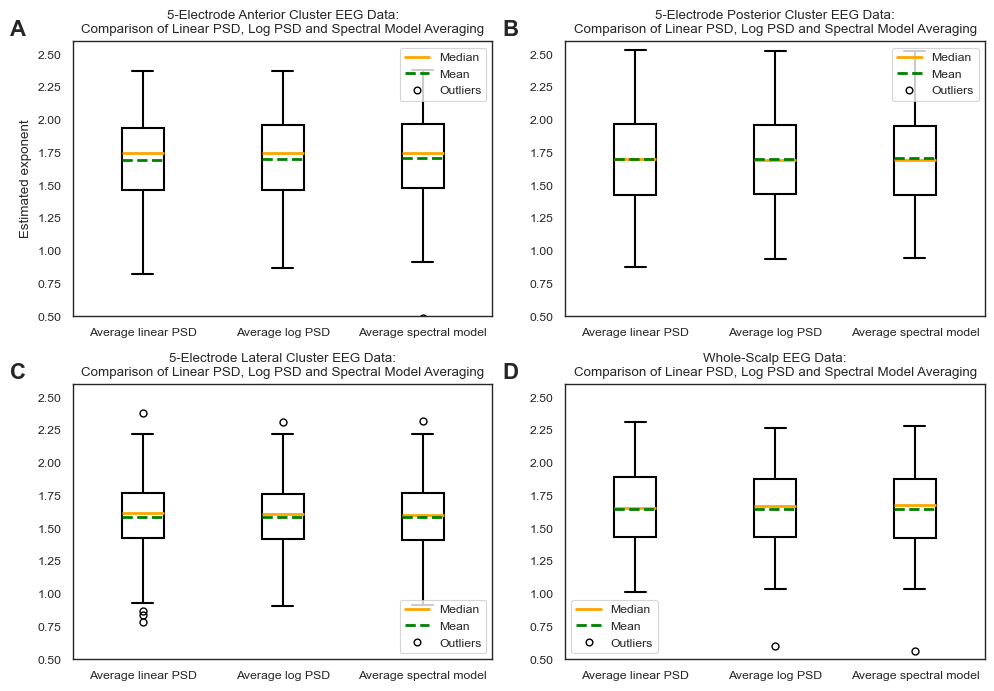

In [38]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharey=False,
)

axes = axes.ravel()

panel_posthoc_results = {}

for i, panel in enumerate(location_panels):
    plot_summary_boxplots(
        summary_paths=panel["summary_paths"],
        labels=labels,
        title=panel["title"],
        ylabel="Estimated exponent" if i == 0 else "",
        ylim=common_ylim,
        ax=axes[i],
        show=False,
    )

    # Select the data in this panel/location.
    panel_data = df_2way.loc[
        df_2way["location"] == panel["location"]
    ]

    # Runs Tukey HSD within this location, adds significant brackets,
    # and returns p-values plus Cohen's d.
    panel_posthoc = add_panel_tukey_brackets(
        ax=axes[i],
        panel_data=panel_data,
        base_ylim=common_ylim,
        labels=labels,
    )

    panel_posthoc_results[panel["location"]] = panel_posthoc

    print(f"\nPost-hoc results: {panel['location']}")
    print(panel_posthoc.round(3))


# Add A, B, C, and D panel labels.
for ax, letter in zip(axes, ["A", "B", "C", "D"]):
    ax.text(
        -0.15,
        1.08,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\Figure7.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### Figure 8

In [60]:
common_ylim = (1.25, 1.7)

labels = [
    "Average linear PSD",
    "Average log PSD",
    "Average spectral model",
]

distribution_index = 0

exp_matrix = generate_2D_exponent_matrix(
    grid_shape=(1, 5),
    exp_range=(-2, -1),
    gradient_axis="cols",
)

true_mean_exp = np.mean(-exp_matrix)

# Information for each spectral-model fitting range
frequency_panels = [
    {
        "fitting_range": "2–10 Hz",
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–10 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3aresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
    },
    {
        "fitting_range": "2–20 Hz",
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–20 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3bresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
    },
    {
        "fitting_range": "2–40 Hz",
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–40 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults1_psd_linear_exp_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp3cresults3_specmod_exp_-1-2.json",
        ],
    },
]

# Build the analysis DataFrame
data_rows = []

for panel in frequency_panels:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "fitting_range": panel["fitting_range"],
            })

df_2way = pd.DataFrame(data_rows)

print(
    df_2way.groupby(["fitting_range", "method"])["estimate"]
    .agg(["count", "mean", "std"])
    .round(3)
)

                                      count   mean    std
fitting_range method                                     
2–10 Hz       Average linear PSD        100  1.493  0.062
              Average log PSD           100  1.496  0.066
              Average spectral model    100  1.509  0.061
2–20 Hz       Average linear PSD        100  1.465  0.047
              Average log PSD           100  1.507  0.045
              Average spectral model    100  1.521  0.039
2–40 Hz       Average linear PSD        100  1.417  0.033
              Average log PSD           100  1.513  0.027
              Average spectral model    100  1.515  0.030


In [61]:
two_way_model = ols(
    "estimate ~ C(method) * C(fitting_range)",
    data=df_2way,
).fit()

two_way_anova = sm.stats.anova_lm(
    two_way_model,
    typ=2,
)

print("\nTwo-way ANOVA: averaging method × fitting range")
print(two_way_anova)

interaction_p = two_way_anova.loc[
    "C(method):C(fitting_range)",
    "PR(>F)",
]

# omnibus effect sizes: partial eta-squared
residual_ss = two_way_anova.loc["Residual", "sum_sq"]

for factor in ["C(method)", "C(fitting_range)", "C(method):C(fitting_range)"]:
    partial_eta_squared = (
        two_way_anova.loc[factor, "sum_sq"]
        / (two_way_anova.loc[factor, "sum_sq"] + residual_ss)
    )
    print(f"{factor} partial eta-squared: {partial_eta_squared:.3f}")

print("\nInteraction p-value:", interaction_p)


Two-way ANOVA: averaging method × fitting range
                              sum_sq     df           F        PR(>F)
C(method)                   0.547322    2.0  121.096574  3.006852e-47
C(fitting_range)            0.057320    2.0   12.682114  3.708228e-06
C(method):C(fitting_range)  0.260519    4.0   28.820248  1.497601e-22
Residual                    2.013534  891.0         NaN           NaN
C(method) partial eta-squared: 0.214
C(fitting_range) partial eta-squared: 0.028
C(method):C(fitting_range) partial eta-squared: 0.115

Interaction p-value: 1.4976013563638018e-22


In [41]:
for fitting_range in df_2way["fitting_range"].unique():
        range_data = df_2way.loc[
            df_2way["fitting_range"] == fitting_range
        ]

        _, range_posthoc = tukey_with_cohens_d(
            range_data,
            "method",
        )

        print(f"\nMethod comparisons within {fitting_range}:")
        print(range_posthoc.round(3))



Method comparisons within 2–10 Hz:
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.003       0.939   
1  Average linear PSD  Average spectral model            0.015       0.200   
2     Average log PSD  Average spectral model            0.012       0.353   

   ci_lower  ci_upper  significant  cohens_d  
0    -0.018     0.024        False    -0.047  
1    -0.006     0.036        False    -0.249  
2    -0.009     0.033        False    -0.193  

Method comparisons within 2–20 Hz:
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.042       0.000   
1  Average linear PSD  Average spectral model            0.056       0.000   
2     Average log PSD  Average spectral model            0.014       0.062   

   ci_lower  ci_upper  significant  cohens_d  
0     0.027     0.056         True    -0.913  
1     0.041     0.07


Post-hoc comparisons: 2–10 Hz
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.003       0.939   
1  Average linear PSD  Average spectral model            0.015       0.200   
2     Average log PSD  Average spectral model            0.012       0.353   

   ci_lower  ci_upper  significant  cohens_d  
0    -0.018     0.024        False    -0.047  
1    -0.006     0.036        False    -0.249  
2    -0.009     0.033        False    -0.193  

Post-hoc comparisons: 2–20 Hz
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.042       0.000   
1  Average linear PSD  Average spectral model            0.056       0.000   
2     Average log PSD  Average spectral model            0.014       0.062   

   ci_lower  ci_upper  significant  cohens_d  
0     0.027     0.056         True    -0.913  
1     0.041     0.071         

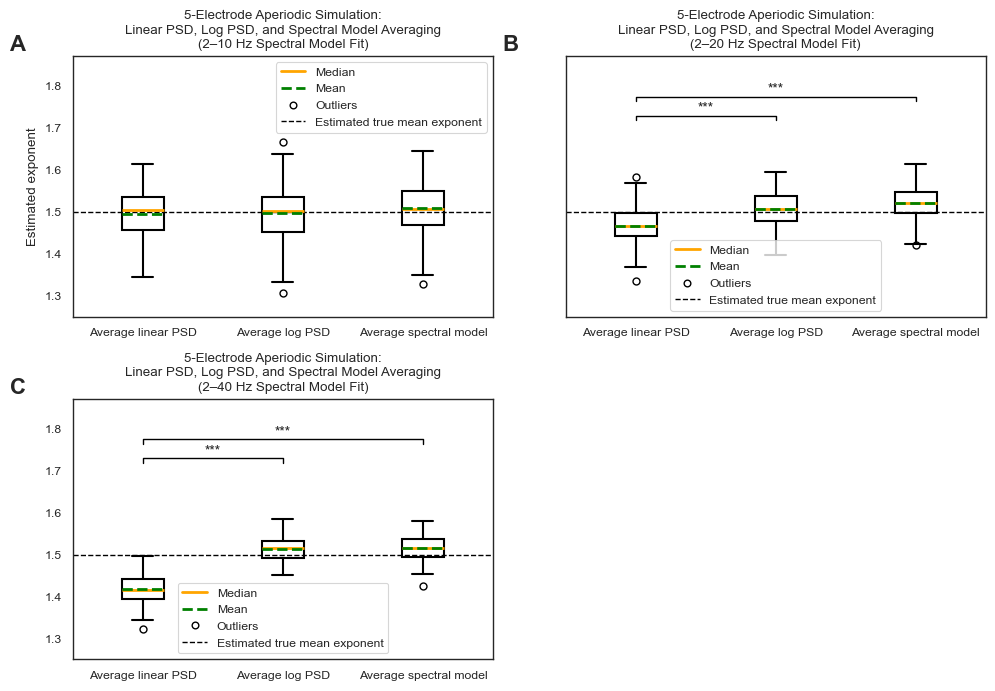

In [42]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharey=True,
)

axes = axes.ravel()

panel_posthoc_results = {}

for i, panel in enumerate(frequency_panels):
    plot_summary_boxplots(
        summary_paths=panel["summary_paths"],
        labels=labels,
        title=panel["title"],
        true_mean_exp=true_mean_exp,
        ylim=common_ylim,
        ylabel="Estimated exponent" if i == 0 else "",
        ax=axes[i],
        show=False,
    )

    panel_data = df_2way.loc[
        df_2way["fitting_range"] == panel["fitting_range"]
    ]

    panel_posthoc = add_panel_tukey_brackets(
        ax=axes[i],
        panel_data=panel_data,
        base_ylim=common_ylim,
        labels=labels,
    )

    panel_posthoc_results[panel["fitting_range"]] = panel_posthoc

    print(f"\nPost-hoc comparisons: {panel['fitting_range']}")
    print(panel_posthoc.round(3))


axes[3].axis("off")

for ax, letter in zip(axes[:3], ["A", "B", "C"]):
    ax.text(
        -0.15,
        1.08,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\Figure8.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### Figure 9

In [62]:
common_ylim = (1.3, 1.6)
first_ylim = (-0.5, 1.6)

labels = [
    "Average linear PSD",
    "Average log PSD",
    "Average spectral model",
]

distribution_index = 0

exp_matrix = generate_2D_exponent_matrix(
    grid_shape=(1, 5),
    exp_range=(-2, -1),
    gradient_axis="cols",
)

true_mean_exp = np.mean(-exp_matrix)

# Panels / fitting-range conditions
frequency_panels = [
    {
        "fitting_range": "2–10 Hz",
        "axis_index": 0,
        "ylim": first_ylim,
        "title": (
            "5-Electrode Combined Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–10 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3aresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3aresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3aresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
    },
    {
        "fitting_range": "2–20 Hz",
        "axis_index": 2,
        "ylim": common_ylim,
        "title": (
            "5-Electrode Combined Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–20 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3bresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3bresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3bresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
    },
    {
        "fitting_range": "2–40 Hz",
        "axis_index": 3,
        "ylim": common_ylim,
        "title": (
            "5-Electrode Combined Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–40 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3cresults1_psd_linear_exp_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3cresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\Combined\exp3cresults3_specmod_exp_-1-2.json",
        ],
    },
]

# Build DataFrame for the ANOVA
data_rows = []

for panel in frequency_panels:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "fitting_range": panel["fitting_range"],
            })

df_2way = pd.DataFrame(data_rows)

print(
    df_2way.groupby(["fitting_range", "method"])["estimate"]
    .agg(["count", "mean", "std"])
    .round(3)
)

                                      count   mean    std
fitting_range method                                     
2–10 Hz       Average linear PSD        100  0.054  0.039
              Average log PSD           100  0.030  0.037
              Average spectral model    100  0.045  0.040
2–20 Hz       Average linear PSD        100  1.462  0.033
              Average log PSD           100  1.515  0.031
              Average spectral model    100  1.519  0.030
2–40 Hz       Average linear PSD        100  1.499  0.015
              Average log PSD           100  1.498  0.019
              Average spectral model    100  1.498  0.019


In [63]:
two_way_model = ols(
    "estimate ~ C(method) * C(fitting_range)",
    data=df_2way,
).fit()

two_way_anova = sm.stats.anova_lm(
    two_way_model,
    typ=2,
)

print("\nTwo-way ANOVA: averaging method × fitting range")
print(two_way_anova)

interaction_p = two_way_anova.loc[
    "C(method):C(fitting_range)",
    "PR(>F)",
]

# omnibus effect sizes: partial eta-squared
residual_ss = two_way_anova.loc["Residual", "sum_sq"]

for factor in ["C(method)", "C(fitting_range)", "C(method):C(fitting_range)"]:
    partial_eta_squared = (
        two_way_anova.loc[factor, "sum_sq"]
        / (two_way_anova.loc[factor, "sum_sq"] + residual_ss)
    )
    print(f"{factor} partial eta-squared: {partial_eta_squared:.3f}")

print("\nInteraction p-value:", interaction_p)


Two-way ANOVA: averaging method × fitting range
                                sum_sq     df              F        PR(>F)
C(method)                     0.037042    2.0      19.852333  3.671297e-09
C(fitting_range)            423.845678    2.0  227156.192923  0.000000e+00
C(method):C(fitting_range)    0.198352    4.0      53.152485  3.426200e-40
Residual                      0.831249  891.0            NaN           NaN
C(method) partial eta-squared: 0.043
C(fitting_range) partial eta-squared: 0.998
C(method):C(fitting_range) partial eta-squared: 0.193

Interaction p-value: 3.4261995346713742e-40


In [45]:
for fitting_range in df_2way["fitting_range"].unique():
        range_data = df_2way.loc[
            df_2way["fitting_range"] == fitting_range
        ]

        _, range_posthoc = tukey_with_cohens_d(
            range_data,
            "method",
        )

        print(f"\nMethod comparisons within {fitting_range}:")
        print(range_posthoc.round(3))


Method comparisons within 2–10 Hz:
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD           -0.024       0.000   
1  Average linear PSD  Average spectral model           -0.010       0.189   
2     Average log PSD  Average spectral model            0.015       0.019   

   ci_lower  ci_upper  significant  cohens_d  
0    -0.037    -0.012         True     0.642  
1    -0.022     0.003        False     0.242  
2     0.002     0.028         True    -0.385  

Method comparisons within 2–20 Hz:
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.054       0.000   
1  Average linear PSD  Average spectral model            0.057       0.000   
2     Average log PSD  Average spectral model            0.004       0.696   

   ci_lower  ci_upper  significant  cohens_d  
0     0.043     0.064         True    -1.674  
1     0.047     0.06


Post-hoc results: 2–10 Hz
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD           -0.024       0.000   
1  Average linear PSD  Average spectral model           -0.010       0.189   
2     Average log PSD  Average spectral model            0.015       0.019   

   ci_lower  ci_upper  significant  cohens_d  
0    -0.037    -0.012         True     0.642  
1    -0.022     0.003        False     0.242  
2     0.002     0.028         True    -0.385  

Post-hoc results: 2–20 Hz
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.054       0.000   
1  Average linear PSD  Average spectral model            0.057       0.000   
2     Average log PSD  Average spectral model            0.004       0.696   

   ci_lower  ci_upper  significant  cohens_d  
0     0.043     0.064         True    -1.674  
1     0.047     0.068         True    

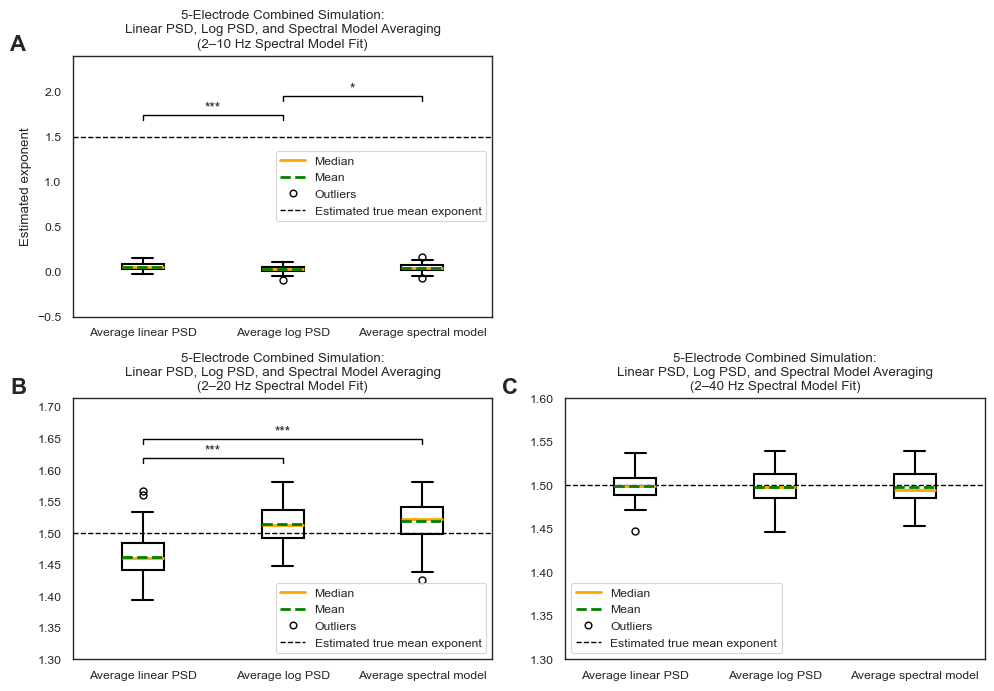

In [46]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharey=False,
)

axes = axes.ravel()

panel_posthoc_results = {}

for panel in frequency_panels:
    axis_index = panel["axis_index"]
    ax = axes[axis_index]

    plot_summary_boxplots(
        summary_paths=panel["summary_paths"],
        labels=labels,
        title=panel["title"],
        true_mean_exp=true_mean_exp,
        ylim=panel["ylim"],
        ylabel="Estimated exponent" if axis_index == 0 else "",
        ax=ax,
        show=False,
    )

    panel_data = df_2way.loc[
        df_2way["fitting_range"] == panel["fitting_range"]
    ]

    panel_posthoc = add_panel_tukey_brackets(
        ax=ax,
        panel_data=panel_data,
        base_ylim=panel["ylim"],
        labels=labels,
    )

    panel_posthoc_results[panel["fitting_range"]] = panel_posthoc

    print(f"\nPost-hoc results: {panel['fitting_range']}")
    print(panel_posthoc.round(3))


# Hide the unused top-right panel.
axes[1].axis("off")

# Label only visible panels.
for axis_index, letter in [(0, "A"), (2, "B"), (3, "C")]:
    axes[axis_index].text(
        -0.15,
        1.08,
        letter,
        transform=axes[axis_index].transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\Figure9.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### Figure 10

                                      count   mean    std
fitting_range method                                     
2–10 Hz       Average linear PSD        111  0.502  0.780
              Average log PSD           111  0.523  0.751
              Average spectral model    111  0.491  0.752
2–20 Hz       Average linear PSD        111  1.378  0.370
              Average log PSD           111  1.369  0.365
              Average spectral model    111  1.375  0.365
2–40 Hz       Average linear PSD        111  1.701  0.331
              Average log PSD           111  1.700  0.315
              Average spectral model    111  1.706  0.320

Two-way ANOVA: averaging method × fitting range
                                sum_sq     df           F         PR(>F)
C(method)                     0.009130    2.0    0.016761   9.833793e-01
C(fitting_range)            254.744601    2.0  467.649066  1.030188e-143
C(method):C(fitting_range)    0.058292    4.0    0.053505   9.946577e-01
Residual             

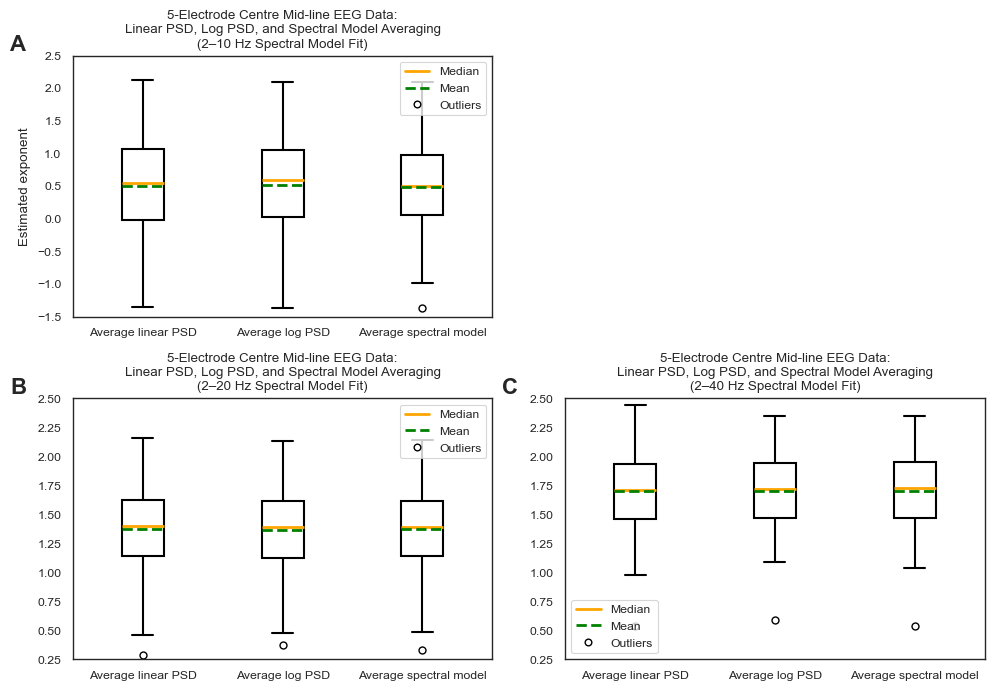

In [66]:
common_ylim = (0.25, 2.5)
first_ylim = (-1.5, 2.5)

labels = [
    "Average linear PSD",
    "Average log PSD",
    "Average spectral model",
]

distribution_index = 0

frequency_panels = [
    {
        "fitting_range": "2–10 Hz",
        "axis_index": 0,
        "ylim": first_ylim,
        "title": (
            "5-Electrode Centre Mid-line EEG Data:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–10 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults1_eeg_psd_linear_5elec_midline.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults2_eeg_psd_log_5elec_midline.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults3_eeg_specmod_5elec_midline.json",
        ],
    },
    {
        "fitting_range": "2–20 Hz",
        "axis_index": 2,
        "ylim": common_ylim,
        "title": (
            "5-Electrode Centre Mid-line EEG Data:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–20 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults1_eeg_psd_linear_5elec_midline.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults2_eeg_psd_log_5elec_midline.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults3_eeg_specmod_5elec_midline.json",
        ],
    },
    {
        "fitting_range": "2–40 Hz",
        "axis_index": 3,
        "ylim": common_ylim,
        "title": (
            "5-Electrode Centre Mid-line EEG Data:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(2–40 Hz Spectral Model Fit)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults1_eeg_psd_linear_5elec_midline.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults2_eeg_psd_log_5elec_midline.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults3_eeg_specmod_5elec_midline.json",
        ],
    },
]


# Build the DataFrame used for ANOVA.
data_rows = []

for panel in frequency_panels:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "fitting_range": panel["fitting_range"],
            })

df_2way = pd.DataFrame(data_rows)

print(
    df_2way.groupby(["fitting_range", "method"])["estimate"]
    .agg(["count", "mean", "std"])
    .round(3)
)


# Two-way ANOVA with the interaction.
two_way_model = ols(
    "estimate ~ C(method) * C(fitting_range)",
    data=df_2way,
).fit()

two_way_anova = sm.stats.anova_lm(two_way_model, typ=2)

print("\nTwo-way ANOVA: averaging method × fitting range")
print(two_way_anova)

interaction_p = two_way_anova.loc[
    "C(method):C(fitting_range)",
    "PR(>F)",
]

# omnibus effect sizes: partial eta-squared
residual_ss = two_way_anova.loc["Residual", "sum_sq"]

for factor in ["C(method)", "C(fitting_range)", "C(method):C(fitting_range)"]:
    partial_eta_squared = (
        two_way_anova.loc[factor, "sum_sq"]
        / (two_way_anova.loc[factor, "sum_sq"] + residual_ss)
    )
    print(f"{factor} partial eta-squared: {partial_eta_squared:.3f}")

print("\nInteraction p-value:", interaction_p)


# Post-hoc tests with Cohen's d.
if interaction_p < 0.05:
    print("\nSignificant interaction: method comparisons within each fitting range.")

    for fitting_range in df_2way["fitting_range"].unique():
        range_data = df_2way.loc[
            df_2way["fitting_range"] == fitting_range
        ]

        _, range_posthoc = tukey_with_cohens_d(
            range_data,
            "method",
        )

        print(f"\nMethod comparisons within {fitting_range}:")
        print(range_posthoc.round(3))

else:
    print("\nNo significant interaction: overall main-effect comparisons.")

    _, method_posthoc = tukey_with_cohens_d(
        df_2way,
        "method",
    )

    _, range_posthoc = tukey_with_cohens_d(
        df_2way,
        "fitting_range",
    )

    print("\nOverall averaging-method comparisons:")
    print(method_posthoc.round(3))

    print("\nOverall fitting-range comparisons:")
    print(range_posthoc.round(3))


fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharey=False,
)

axes = axes.ravel()

panel_posthoc_results = {}

for panel in frequency_panels:
    axis_index = panel["axis_index"]
    ax = axes[axis_index]

    plot_summary_boxplots(
        summary_paths=panel["summary_paths"],
        labels=labels,
        title=panel["title"],
        ylim=panel["ylim"],
        ylabel="Estimated exponent" if axis_index == 0 else "",
        ax=ax,
        show=False,
    )

    panel_data = df_2way.loc[
        df_2way["fitting_range"] == panel["fitting_range"]
    ]

    panel_posthoc = add_panel_tukey_brackets(
        ax=ax,
        panel_data=panel_data,
        base_ylim=panel["ylim"],
        labels=labels,
    )

    panel_posthoc_results[panel["fitting_range"]] = panel_posthoc

    print(f"\nPost-hoc results: {panel['fitting_range']}")
    print(panel_posthoc.round(3))


axes[1].axis("off")

for axis_index, letter in [(0, "A"), (2, "B"), (3, "C")]:
    axes[axis_index].text(
        -0.15,
        1.08,
        letter,
        transform=axes[axis_index].transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\Figure10.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

##### Figure 11

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.formula.api import ols

from dissertation_simulations.loading_summaries import load_distribution_summary
from dissertation_simulations.plotting import (
    plot_summary_boxplots,
    tukey_with_cohens_d,
    add_panel_tukey_brackets,
)


# -------------------------------------------------------
# Settings
# -------------------------------------------------------
common_ylim = (1.08, 1.9)

labels = [
    "Average linear PSD",
    "Average log PSD",
    "Average spectral model",
]

distribution_index = 0


# -------------------------------------------------------
# Panel information
# -------------------------------------------------------
outlier_panels = [
    {
        "outlier_extremity": "No outlier",
        "outlier": None,
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(No Outlier)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults1_psd_linear_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults2_psd_log_exp_matrix_cols_-1-2.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp5aresults3_specmod_exp_matrix_cols_-1-2.json",
        ],
    },
    {
        "outlier_extremity": "Outlier: -2.25",
        "outlier": {"value": -2.25, "location": "random"},
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(Random Outlier: -2.25)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults1_psd_linear_exp_matrix_cols_-1-2_outlier-2.25.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults2_psd_log_exp_matrix_cols_-1-2_outlier-2.25.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7aresults3_specmod_exp_matrix_cols_-1-2_outlier-2.25.json",
        ],
    },
    {
        "outlier_extremity": "Outlier: -2.5",
        "outlier": {"value": -2.5, "location": "random"},
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(Random Outlier: -2.5)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults1_psd_linear_exp_matrix_cols_-1-2_outlier-2.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults2_psd_log_exp_matrix_cols_-1-2_outlier-2.5.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7bresults3_specmod_exp_matrix_cols_-1-2_outlier-2.5.json",
        ],
    },
    {
        "outlier_extremity": "Outlier: -3.0",
        "outlier": {"value": -3.0, "location": "random"},
        "title": (
            "5-Electrode Aperiodic Simulation:\n"
            "Linear PSD, Log PSD, and Spectral Model Averaging\n"
            "(Random Outlier: -3.0)"
        ),
        "summary_paths": [
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults1_psd_linear_exp_matrix_cols_-1-2_outlier-3.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults2_psd_log_exp_matrix_cols_-1-2_outlier-3.json",
            r"C:\Users\chloe\DissertationSimulations\Result summaries\1D electrodes\exp7cresults3_specmod_exp_matrix_cols_-1-2_outlier-3.json",
        ],
    },
]


# Calculate the reference line separately for each condition.
for panel in outlier_panels:
    exp_matrix = generate_2D_exponent_matrix(
        grid_shape=(1, 5),
        exp_range=(-2, -1),
        gradient_axis="cols",
        outlier=panel["outlier"],
    )

    panel["true_mean_exp"] = np.mean(-exp_matrix)


# -------------------------------------------------------
# Build DataFrame for the two-way ANOVA
# -------------------------------------------------------
data_rows = []

for panel in outlier_panels:
    for path, method in zip(panel["summary_paths"], labels):
        _, distributions = load_distribution_summary(path)

        estimates = np.asarray(distributions[distribution_index])

        for estimate in estimates:
            data_rows.append({
                "estimate": estimate,
                "method": method,
                "outlier_extremity": panel["outlier_extremity"],
            })

df_2way = pd.DataFrame(data_rows)

print(
    df_2way.groupby(["outlier_extremity", "method"])["estimate"]
    .agg(["count", "mean", "std"])
    .round(3)
)


# -------------------------------------------------------
# Two-way independent ANOVA with interaction
# -------------------------------------------------------
two_way_model = ols(
    "estimate ~ C(method) * C(outlier_extremity)",
    data=df_2way,
).fit()

two_way_anova = sm.stats.anova_lm(
    two_way_model,
    typ=2,
)

print("\nTwo-way ANOVA: averaging method × outlier extremity")
print(two_way_anova)

interaction_p = two_way_anova.loc[
    "C(method):C(outlier_extremity)",
    "PR(>F)",
]

# omnibus effect sizes: partial eta-squared
residual_ss = two_way_anova.loc["Residual", "sum_sq"]

for factor in ["C(method)", "C(outlier_extremity)", "C(method):C(outlier_extremity)"]:
    partial_eta_squared = (
        two_way_anova.loc[factor, "sum_sq"]
        / (two_way_anova.loc[factor, "sum_sq"] + residual_ss)
    )
    print(f"{factor} partial eta-squared: {partial_eta_squared:.3f}")


print("\nInteraction p-value:", interaction_p)

                                          count   mean    std
outlier_extremity method                                     
No outlier        Average linear PSD        100  1.421  0.032
                  Average log PSD           100  1.510  0.024
                  Average spectral model    100  1.520  0.025
Outlier: -2.25    Average linear PSD        100  1.647  0.032
                  Average log PSD           100  1.770  0.030
                  Average spectral model    100  1.778  0.028
Outlier: -2.5     Average linear PSD        100  1.461  0.035
                  Average log PSD           100  1.661  0.028
                  Average spectral model    100  1.669  0.030
Outlier: -3.0     Average linear PSD        100  1.452  0.037
                  Average log PSD           100  1.776  0.025
                  Average spectral model    100  1.778  0.025

Two-way ANOVA: averaging method × outlier extremity
                                   sum_sq      df            F         PR(>F)
C

In [49]:
if interaction_p < 0.05:
    print(
        "\nSignificant interaction: "
        "testing method effects within each outlier condition."
    )

    # Method comparisons within each outlier condition.
    for condition in df_2way["outlier_extremity"].unique():
        condition_data = df_2way.loc[
            df_2way["outlier_extremity"] == condition
        ]

        _, method_posthoc = tukey_with_cohens_d(
            condition_data,
            "method",
        )

        print(f"\nMethod comparisons within: {condition}")
        print(method_posthoc.round(3))

    # Outlier-condition comparisons within each method.
    for method in labels:
        method_data = df_2way.loc[
            df_2way["method"] == method
        ]

        _, outlier_posthoc = tukey_with_cohens_d(
            method_data,
            "outlier_extremity",
        )

        print(f"\nOutlier-condition comparisons within: {method}")
        print(outlier_posthoc.round(3))

else:
    print(
        "\nNo significant interaction: "
        "testing overall main effects."
    )

    _, method_posthoc = tukey_with_cohens_d(
        df_2way,
        "method",
    )

    _, outlier_posthoc = tukey_with_cohens_d(
        df_2way,
        "outlier_extremity",
    )

    print("\nOverall averaging-method comparisons:")
    print(method_posthoc.round(3))

    print("\nOverall outlier-extremity comparisons:")
    print(outlier_posthoc.round(3))


Significant interaction: testing method effects within each outlier condition.

Method comparisons within: No outlier
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.089       0.000   
1  Average linear PSD  Average spectral model            0.100       0.000   
2     Average log PSD  Average spectral model            0.011       0.014   

   ci_lower  ci_upper  significant  cohens_d  
0     0.080     0.098         True    -3.110  
1     0.090     0.109         True    -3.459  
2     0.002     0.020         True    -0.451  

Method comparisons within: Outlier: -2.25
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.123       0.000   
1  Average linear PSD  Average spectral model            0.131       0.000   
2     Average log PSD  Average spectral model            0.008       0.128   

   ci_lower  ci_upper  s


Post-hoc results: No outlier
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.089       0.000   
1  Average linear PSD  Average spectral model            0.100       0.000   
2     Average log PSD  Average spectral model            0.011       0.014   

   ci_lower  ci_upper  significant  cohens_d  
0     0.080     0.098         True    -3.110  
1     0.090     0.109         True    -3.459  
2     0.002     0.020         True    -0.451  

Post-hoc results: Outlier: -2.25
               group1                  group2  mean_difference  p_adjusted  \
0  Average linear PSD         Average log PSD            0.123       0.000   
1  Average linear PSD  Average spectral model            0.131       0.000   
2     Average log PSD  Average spectral model            0.008       0.128   

   ci_lower  ci_upper  significant  cohens_d  
0     0.113     0.133         True    -4.005  
1     0.121     0.141       

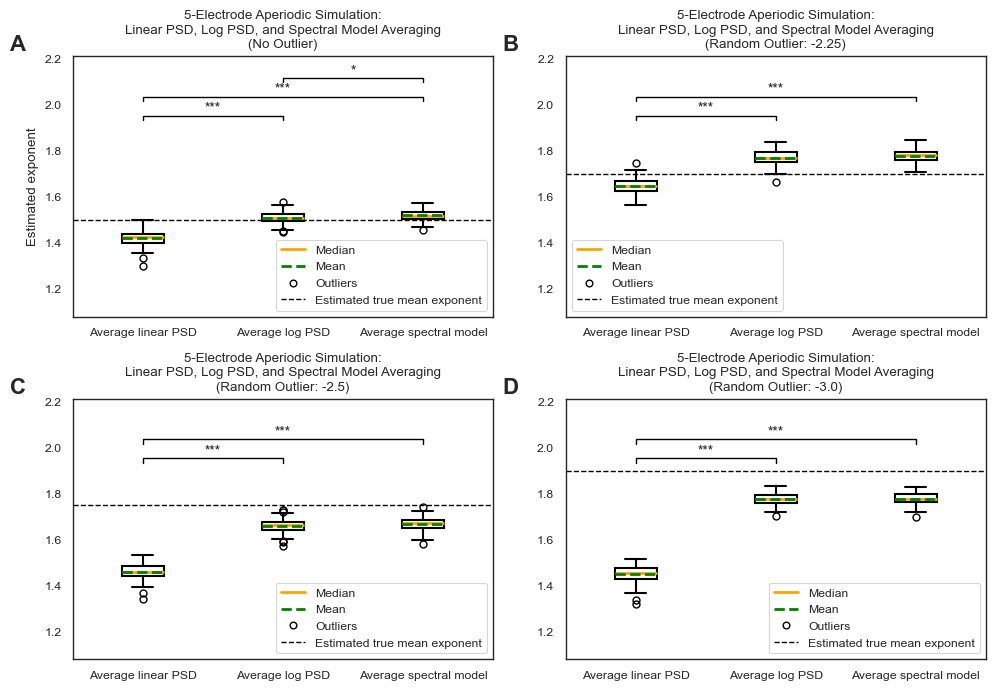

In [50]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharey=False,
)

axes = axes.ravel()

panel_posthoc_results = {}

for i, panel in enumerate(outlier_panels):
    plot_summary_boxplots(
        summary_paths=panel["summary_paths"],
        labels=labels,
        title=panel["title"],
        true_mean_exp=panel["true_mean_exp"],
        ylim=common_ylim,
        ylabel="Estimated exponent" if i == 0 else "",
        ax=axes[i],
        show=False,
    )

    panel_data = df_2way.loc[
        df_2way["outlier_extremity"] == panel["outlier_extremity"]
    ]

    # Adds Tukey-significant brackets and returns Cohen's d post-hoc table.
    panel_posthoc = add_panel_tukey_brackets(
        ax=axes[i],
        panel_data=panel_data,
        base_ylim=common_ylim,
        labels=labels,
    )

    panel_posthoc_results[panel["outlier_extremity"]] = panel_posthoc

    print(f"\nPost-hoc results: {panel['outlier_extremity']}")
    print(panel_posthoc.round(3))


for ax, letter in zip(axes, ["A", "B", "C", "D"]):
    ax.text(
        -0.15,
        1.08,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

fig.tight_layout()

fig.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures Final\Figure11.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()